In [160]:
import pygame
import sys
import pickle
import os

# Dimensiones de la ventana
WIDTH, HEIGHT = 800, 800
# Dimensiones de la cuadrícula
ROWS, COLS = 8, 8
# Tamaño de cada casilla
SQUARE_SIZE = WIDTH//COLS

# Colores
WHITE = (255, 255, 255)
GRAY = (200, 200, 200)
RED = (174, 230, 255)


def draw_grid(win, rows, cols, square_size, selected):
    for i in range(rows):
        for j in range(cols):
            color = RED if (i, j) in selected else WHITE
            pygame.draw.rect(win, color, (j*square_size, i*square_size, square_size, square_size))
            pygame.draw.rect(win, GRAY, (j*square_size, i*square_size, square_size, square_size), 1)


def seleccionar_casillas():
    pygame.init()
    WIN = pygame.display.set_mode((WIDTH, HEIGHT))
    clock = pygame.time.Clock()

    selected = set()

    while True:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return list(selected)
            if event.type == pygame.MOUSEBUTTONDOWN or event.type == pygame.MOUSEMOTION and event.buttons[0] == 1:
                pos = pygame.mouse.get_pos()
                row, col = pos[1] // SQUARE_SIZE, pos[0] // SQUARE_SIZE
                if (row, col) not in selected:
                    selected.add((row, col))
            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_RETURN:
                    pygame.quit()
                    return list(selected)

        WIN.fill(WHITE)
        draw_grid(WIN, ROWS, COLS, SQUARE_SIZE, selected)
        pygame.display.update()
        clock.tick(60)


if __name__ == "__main__":
    if not os.path.exists('casillas_seleccionadas.pkl'):
        try:
            casillas_seleccionadas = seleccionar_casillas()
            print("Las casillas seleccionadas son:")
            for row, col in casillas_seleccionadas:
                print(f'Fila {row+1}, Columna {col+1}')

            # Guardar la lista en un archivo
            with open('casillas_seleccionadas.pkl', 'wb') as f:
                pickle.dump(casillas_seleccionadas, f)

        except SystemExit:
            pass
    else:
        # Cargar la lista desde un archivo
        with open('casillas_seleccionadas.pkl', 'rb') as f:
            casillas_seleccionadas = pickle.load(f)
        print("Las casillas seleccionadas cargadas desde el archivo son:")
        for row, col in casillas_seleccionadas:
            print(f'Fila {row+1}, Columna {col+1}')

Las casillas seleccionadas cargadas desde el archivo son:
Fila 5, Columna 1
Fila 4, Columna 2
Fila 6, Columna 2
Fila 2, Columna 1
Fila 7, Columna 3
Fila 8, Columna 2
Fila 5, Columna 3
Fila 4, Columna 1
Fila 6, Columna 1
Fila 3, Columna 2
Fila 7, Columna 2
Fila 8, Columna 1
Fila 4, Columna 3
Fila 5, Columna 2
Fila 6, Columna 3
Fila 1, Columna 1
Fila 2, Columna 2
Fila 3, Columna 1
Fila 8, Columna 3
Fila 7, Columna 1


3.3333333333333335 6.666666666666667
[[0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.00116279 0.00116279 0.00116279
  0.00116279 0.00116279 0.02325581 0.02325581]
 [0.02325581 0.02325581 0.00116279 0.001162

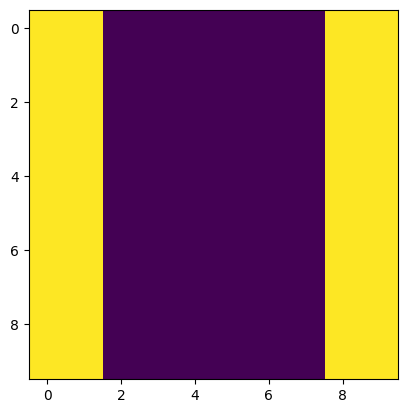

: 

In [161]:
import numpy as np
import matplotlib.pyplot as plt


def initial_state_priv(Eje_x: int, Eje_y: int, num_trampas: int):
    """
    Generate an initial state for a grid with given dimensions and number of traps.

    Parameters:
    - Eje_x (int): The number of rows in the grid.
    - Eje_y (int): The number of columns in the grid.
    - num_trampas (int): The number of traps to be randomly placed in the grid.

    Returns:
    - InitialState (numpy.ndarray): The initial state grid with traps randomly placed.
    """

    # Favorezco que las trampas estén en la parte central de lols bordes
    x_priv = Eje_x/3

    x_priv_inf = x_priv
    x_priv_sup = 2*x_priv

    print(x_priv_inf, x_priv_sup)

    # Create a matrix of zeros with size Eje_x x Eje_y
    InitialState = np.zeros((Eje_x, Eje_y), dtype=int)

    # Generate weights for positions
    pesos_x = np.array([0 if (x == x_priv_inf or x == x_priv_sup) else 0 for x in range(Eje_x)])
    pesos_y = np.array([20 if (y == 0 or y == Eje_y-1 or y == 1 or y == Eje_y-2) else 1 for y in range(Eje_y)])

    # Extend the weights to match the grid size
    pesos = np.concatenate([pesos_x] * Eje_x) + np.concatenate([pesos_y] * Eje_y)

    print((pesos/np.sum(pesos)).reshape(Eje_x, Eje_y))

    # Generate random positions for the traps with weights
    posiciones_unos = np.random.choice(Eje_x * Eje_y, num_trampas, replace=False, p=pesos/np.sum(pesos))

    plt.imshow((pesos/np.sum(pesos)).reshape(Eje_x, Eje_y))

    # Assign the value 1 to the selected positions
    for pos in posiciones_unos:
        fila, columna = divmod(pos, Eje_x)
        InitialState[fila, columna] = 1
    return InitialState


# Example usage:
Eje_x = 10
Eje_y = 10
num_trampas = 20
initial_state = initial_state_priv(Eje_x, Eje_y, num_trampas)
print(initial_state)

In [ ]:
# Supongamos que las imágenes están en el subdirectorio "Figuras" y tienen nombres de archivo que siguen el patrón "image*.png"
filenames = glob.glob('Figuras/grafica*.png')

# Crear una lista para almacenar las imágenes
images = []
k = 1
for matrix in tqdm(configuraciones_matriz):
    # Llamar a tu función para representar la matriz y guardar la imagen
    RepresentateStateOpt(matrix, filename="Figuras/grafica_" + str(k) + ".png")

    plt.savefig((buffer := BytesIO()), format='png')
    plt.close()

    # Leer la imagen guardada y agregarla a la lista de imágenes
    images.append(Image.open(buffer))
    k += 1